In [4]:
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import (
    compute_performance,
    plot_psychometric,
    plot_reaction_time,
    get_signed_contrast,
    compute_reaction_time,
)
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
import os
import concurrent.futures
import functools
from ibl_info.selective_decomposition import run_analysis_single_session, filter_eids
from ibl_info.utils import check_config

In [3]:
important_regions = [
    "VISp",
    "MOs",
    "SSp-ul",
    "ACAd",
    "PL",
    "CP",
    "VPM",
    "MG",
    "LGd",
    "ZI",
    "SNr",
    "MRN",
    "SCm",
    "PAG",
    "APN",
    "RN",
    "PPN",
    "PRNc",
    "PRNr",
    "GRN",
    "IRN",
    "PGRN",
    "CUL4 5",
    "SIM",
    "IP",
]

In [5]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    username="intbrainlab",
    password="international",
)

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [6]:
with open("../data/processed/contrastwiseperformance.pkl", "rb") as f:
    data = pkl.load(f)

In [10]:
data["004d8fd5-41e7-4f1b-a45b-0d4ad76fe446"].keys()

dict_keys(['performance', 'contrasts', 'n_contrasts', 'reaction_time', 'accuracy_array'])

In [11]:
plt.style.use("../figures.style")

In [13]:
performance = []
for eid in data.keys():
    performance.append(data[eid]["performance"])

In [14]:
performance = np.asarray(performance)

In [15]:
performance.shape

(336, 9)

In [22]:
def get_folded_stats(data):
    left_half = data[:, :4]
    right_half = data[:, 5:][:, ::-1]
    middle = data[:, 4:5]
    folded_pairs = (left_half + right_half) / 2

    folded_data = np.hstack([folded_pairs, middle])

    means = np.mean(folded_data, axis=0)
    stds = np.std(folded_data, axis=0)

    return means, stds, folded_data

In [23]:
means, stds, ogdata = get_folded_stats(performance)

In [64]:
ogdata.shape

(336, 5)

In [65]:
col_names = ["0", "0.0625", "0.125", "0.25", "1"]
df = pd.DataFrame(ogdata[:, ::-1], columns=col_names)

In [83]:
plt.style.use("../figures.style")

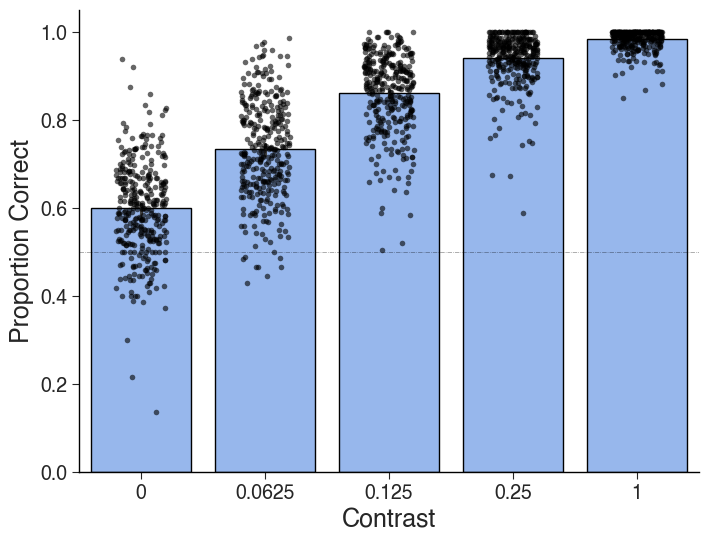

In [180]:
col_names = ["0", "0.0625", "0.125", "0.25", "1"]
df = pd.DataFrame(ogdata[:, ::-1], columns=col_names)
df_long = df.melt(var_name="Contrast", value_name="Accuracy")

# --- 2. PLOTTING ---
fig, ax = plt.subplots(figsize=(8, 6))

# A. The Bar Plot (The Averages)
# ci=68 draws Standard Error bars (similar to SEM). Use ci=95 for confidence interval.
sns.barplot(
    data=df_long,
    x="Contrast",
    y="Accuracy",
    color="#89B4FA",  # Uniform color for bars
    edgecolor="black",  # Black border around bars
    linewidth=1,
    zorder=1,  # Draw this first (bottom layer)
)

sns.stripplot(
    data=df_long,
    x="Contrast",
    y="Accuracy",
    color="black",  # Dark color for points
    size=4,  # Dot size
    alpha=0.6,  # Slight transparency for overlapping points
    jitter=0.2,  # How much to spread them horizontally
    zorder=2,  # Draw this second (top layer)
)
ax.set_ylabel("Proportion Correct")
ax.axhline(0.5, color="k", linestyle="-.", alpha=0.45, linewidth=0.5)
plt.savefig(
    "../reports/figures/mouse_performance.svg", facecolor="white", bbox_inches="tight", dpi=300
)

In [136]:
accuracy_array = []
for eid in data.keys():
    accuracy_array.append(data[eid]["accuracy_array"])

In [137]:
accuracy_array = np.asarray(accuracy_array)

In [138]:
accuracy_array.shape

(336, 9, 2)

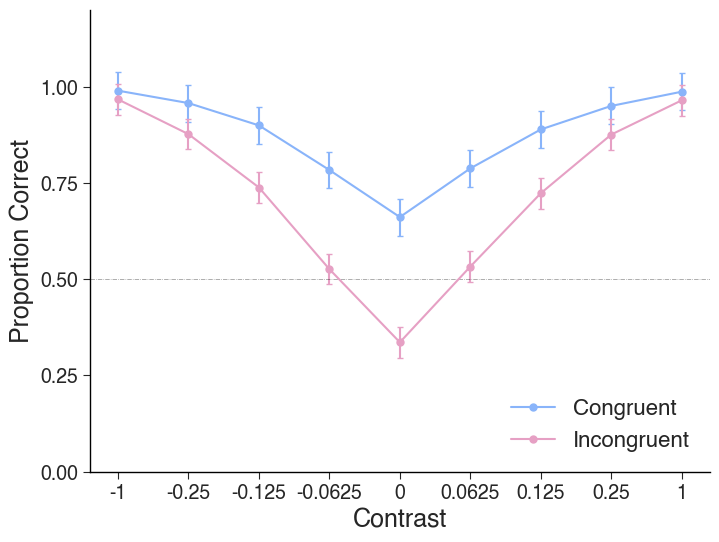

In [179]:
fig, ax = plt.subplots(figsize=(8, 6))

data_line1, cap_lines, bar_lines = ax.errorbar(
    x=np.arange(9),
    y=np.nanmean(accuracy_array[:, :, 0], axis=0),
    marker=".",
    yerr=np.nanmean(accuracy_array[:, :, 0]) / np.sqrt(len(accuracy_array)),
    capsize=2,
    label="Congruent",
)

data_line2, cap_lines, bar_lines = ax.errorbar(
    x=np.arange(9),
    y=np.nanmean(accuracy_array[:, :, 1], axis=0),
    marker=".",
    yerr=np.nanmean(accuracy_array[:, :, 1]) / np.sqrt(len(accuracy_array)),
    capsize=2,
    label="Incongruent",
)
ax.set_ylim(0, 1.2)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.axhline(0.5, color="k", linestyle="-.", alpha=0.45, linewidth=0.5)
ax.legend(
    [data_line1, data_line2],
    ["Congruent", "Incongruent"],
    loc="lower right",
    fontsize=16,
    markerscale=1,
)
ax.set_xticks(
    np.arange(9), ["-1", "-0.25", "-0.125", "-0.0625", "0", "0.0625", "0.125", "0.25", "1"]
)
ax.set_xlabel("Contrast")
ax.set_ylabel("Proportion Correct")
plt.savefig(
    "../reports/figures/mouse_performance_congruence.svg",
    facecolor="white",
    bbox_inches="tight",
    dpi=300,
)

In [142]:
reaction_times = []
for eid in data.keys():
    reaction_times.append(data[eid]["reaction_time"])

In [143]:
reaction_times = np.asarray(reaction_times)

In [144]:
reaction_times.shape

(336, 9)

In [145]:
reaction_means, reaction_stds, og_reactions = get_folded_stats(reaction_times)

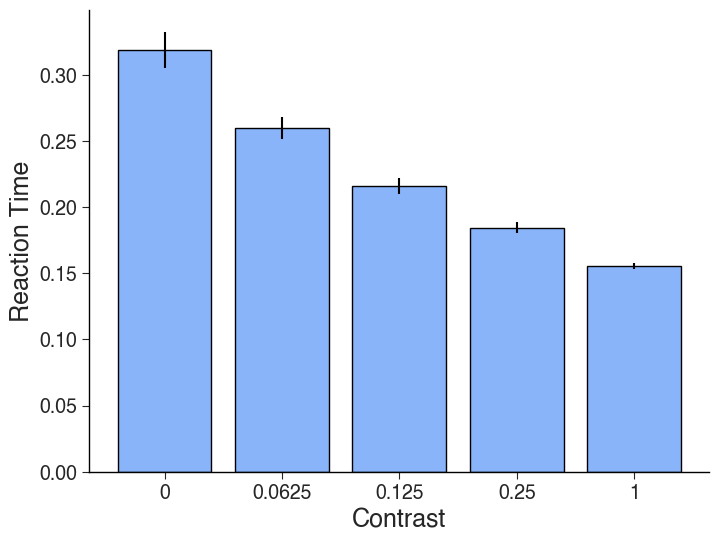

In [169]:
# col_names = ["0", "0.0625", "0.125", "0.25", "1"]
# df = pd.DataFrame(og_reactions[:, ::-1], columns=col_names)
# df_long = df.melt(var_name="Contrast", value_name="Reaction Time")


fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    x=np.arange(5),
    height=reaction_means[::-1],
    color="#89B4FA",  # Uniform color for bars
    edgecolor="black",  # Black border around bars
    yerr=reaction_stds[::-1] / np.sqrt(reaction_times.shape[0]),
    linewidth=1,
)


ax.set_ylabel("Reaction Time")
ax.set_xticks(np.arange(5), ["0", "0.0625", "0.125", "0.25", "1"])
ax.set_xlabel("Contrast")
plt.savefig(
    "../reports/figures/mouse_reaction.svg", facecolor="white", bbox_inches="tight", dpi=300
)

In [172]:
subject_id = "CSH_ZAD_022"
eid = "a82800ce-f4e3-4464-9b80-4c3d6fade333"
session_id = eid
ss = SessionLoader(one, eid=session_id)
ss.load_trials()
trials, mask = load_trials_and_mask(
    one, session_id, exclude_nochoice=False, exclude_unbiased=False
)
trials = trials[mask]

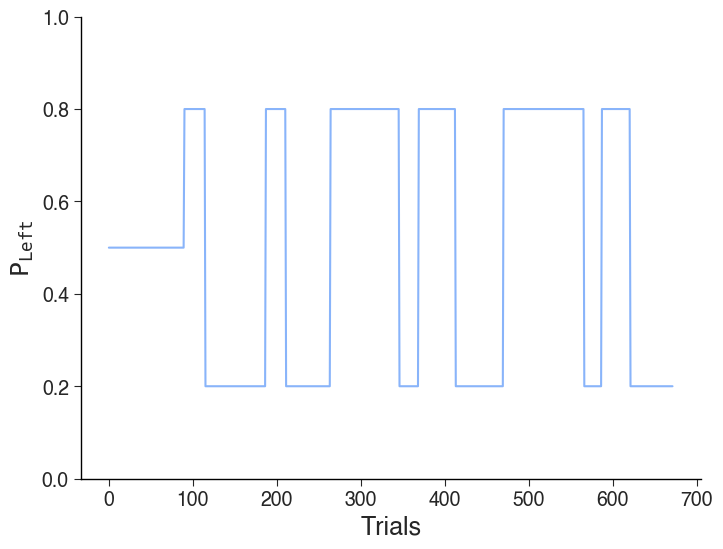

In [176]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ss.trials["probabilityLeft"])
ax.set_ylim(0, 1)
sns.despine()
ax.set_xlabel("Trials")
ax.set_ylabel("$\mathtt{P_{Left}}$")
plt.savefig(
    "../reports/figures/sample_session.svg", facecolor="white", bbox_inches="tight", dpi=300
)